# Federal R&D Budgets Data

This dataset contains U.S. federal research and development (R&D) budget allocations 
across 14 government departments from 1976 to 2017, alongside annual GDP figures.

**Source:** `fed_rd_year&gdp.csv`  
**Rows:** 588 | **Departments:** 14 | **Years:** 1976–2017

### Departments Included
DHS, DOC, DOD, DOE, DOT, EPA, HHS, Interior, NASA, NIH, NSF, Other, USDA, VA

### Key Variables
| Column | Description |
|---|---|
| `department` | Federal government department |
| `year` | Fiscal year |
| `rd_budget` | R&D budget allocation (USD) |
| `gdp` | U.S. GDP for that year (USD) |

### Goal
The goal of this project was to tidy the dataset by reshaping it from a wide format, where each year was its own column, into a long format with clean, analysis-ready columns: `department`, `year`, `rd_budget`, and `gdp`.

## Step 1: Import Libraries & Load Data

Import the necessary libraries and load the dataset into a pandas DataFrame.
An initial inspection is performed using `.head()`, `.shape`, `.info()`, and `.columns` 
to understand the structure of the raw data before any cleaning.


In [157]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("fed_rd_year&gdp.csv")
display(df.head())
print(df.shape)
print(df.info())
print(df.columns.to_list())

,department,1976_gdp1790000000000.0,1977_gdp2028000000000.0,1978_gdp2278000000000.0,1979_gdp2570000000000.0,1980_gdp2797000000000.0,1981_gdp3138000000000.0,1982_gdp3314000000000.0,1983_gdp3541000000000.0,1984_gdp3953000000000.0,...,2008_gdp14752000000000.0,2009_gdp14415000000000.0,2010_gdp14799000000000.0,2011_gdp15379000000000.0,2012_gdp16027000000000.0,2013_gdp16516000000000.0,2014_gdp17244000000000.0,2015_gdp17983000000000.0,2016_gdp18470000000000.0,2017_gdp19177000000000.0
0,DHS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1155000000,1258000000,1009000000,848000000,527000000,737000000,1092000000,960000000,602000000,735000000
1,DOC,8.190000e+08,8.370000e+08,8.710000e+08,9.520000e+08,9.450000e+08,8.290000e+08,6.930000e+08,7.000000e+08,7.550000e+08,...,1379000000,1594000000,1521000000,1357000000,1373000000,1397000000,1641000000,1596000000,1730000000,1824000000
2,DOD,3.569600e+10,3.796700e+10,3.702200e+10,3.717400e+10,3.700500e+10,4.173700e+10,4.689300e+10,5.100800e+10,5.813900e+10,...,94247000000,93527000000,94325000000,88220000000,81543000000,70583000000,70341000000,69522000000,75213000000,51862000000
3,DOE,1.088200e+10,1.374100e+10,1.566300e+10,1.561200e+10,1.522600e+10,1.479800e+10,1.216000e+10,1.112900e+10,1.173100e+10,...,11343000000,11823000000,12329000000,11902000000,11839000000,11528000000,12686000000,15033000000,15504000000,15032000000
4,DOT,1.142000e+09,1.095000e+09,1.156000e+09,1.004000e+09,1.048000e+09,9.780000e+08,7.020000e+08,8.000000e+08,1.018000e+09,...,1016000000,1062000000,1221000000,1064000000,1007000000,881000000,843000000,926000000,910000000,936000000


(14, 43)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 43 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   department                14 non-null     object 
 1   1976_gdp1790000000000.0   13 non-null     float64
 2   1977_gdp2028000000000.0   13 non-null     float64
 3   1978_gdp2278000000000.0   13 non-null     float64
 4   1979_gdp2570000000000.0   13 non-null     float64
 5   1980_gdp2797000000000.0   13 non-null     float64
 6   1981_gdp3138000000000.0   13 non-null     float64
 7   1982_gdp3314000000000.0   13 non-null     float64
 8   1983_gdp3541000000000.0   13 non-null     float64
 9   1984_gdp3953000000000.0   13 non-null     float64
 10  1985_gdp4270000000000.0   13 non-null     float64
 11  1986_gdp4536000000000.0   13 non-null     float64
 12  1987_gdp4782000000000.0   13 non-null     float64
 13  1988_gdp5155000000000.0   13 non-null     float64
 14  198

## Step 2: Melt the DataFrame

The raw data was in **wide format**, each year had its own column (e.g. `1976_gdp1790000000000.0`).
Using `pd.melt()`, the data is reshaped into **long format**, keeping `department` fixed 
and collapsing all year columns into two new columns: `year` and `rd_budget`.

This is the core tidying step, reducing 43 columns down to 3.


In [158]:
# Melting dataframe: Coverting columns into year and GDP value columns.
df = pd.melt(df, id_vars = ["department"], value_vars= ['1976_gdp1790000000000.0', '1977_gdp2028000000000.0', '1978_gdp2278000000000.0', '1979_gdp2570000000000.0', '1980_gdp2797000000000.0', '1981_gdp3138000000000.0', '1982_gdp3314000000000.0', '1983_gdp3541000000000.0', '1984_gdp3953000000000.0', '1985_gdp4270000000000.0', '1986_gdp4536000000000.0', '1987_gdp4782000000000.0', '1988_gdp5155000000000.0', '1989_gdp5570000000000.0', '1990_gdp5915000000000.0', '1991_gdp6110000000000.0', '1992_gdp6435000000000.0', '1993_gdp6795000000000.0', '1994_gdp7198000000000.0', '1995_gdp7583000000000.0', '1996_gdp7978000000000.0', '1997_gdp8483000000000.0', '1998_gdp8955000000000.0', '1999_gdp9511000000000.0', '2000_gdp10148000000000.0', '2001_gdp10565000000000.0', '2002_gdp10877000000000.0', '2003_gdp11332000000000.0', '2004_gdp12089000000000.0', '2005_gdp12889000000000.0', '2006_gdp13685000000000.0', '2007_gdp14323000000000.0', '2008_gdp14752000000000.0', '2009_gdp14415000000000.0', '2010_gdp14799000000000.0', '2011_gdp15379000000000.0', '2012_gdp16027000000000.0', '2013_gdp16516000000000.0', '2014_gdp17244000000000.0', '2015_gdp17983000000000.0', '2016_gdp18470000000000.0', '2017_gdp19177000000000.0'],
        var_name = 'year', value_name = "rd_budget")

df

,department,year,rd_budget
0,DHS,1976_gdp1790000000000.0,NaN
1,DOC,1976_gdp1790000000000.0,8.190000e+08
2,DOD,1976_gdp1790000000000.0,3.569600e+10
3,DOE,1976_gdp1790000000000.0,1.088200e+10
4,DOT,1976_gdp1790000000000.0,1.142000e+09
...,...,...,...
583,NIH,2017_gdp19177000000000.0,3.305200e+10
584,NSF,2017_gdp19177000000000.0,6.040000e+09
585,Other,2017_gdp19177000000000.0,1.553000e+09
586,USDA,2017_gdp19177000000000.0,2.625000e+09


## Step 3: Split Year and GDP into Separate Columns

After melting, the `year` column contained combined values like `1976_gdp1790000000000.0`. 
Using `.str.split("_gdp")`, this is separated into two clean columns: `year` and `gdp`, 
giving each variable its own column, a core principle of tidy data.


In [159]:
#  Splitting up columns
df[["year", "gdp"]] = df["year"].str.split("_gdp", n = 1, expand = True)

display(df)

,department,year,rd_budget,gdp
0,DHS,1976,NaN,1790000000000.0
1,DOC,1976,8.190000e+08,1790000000000.0
2,DOD,1976,3.569600e+10,1790000000000.0
3,DOE,1976,1.088200e+10,1790000000000.0
4,DOT,1976,1.142000e+09,1790000000000.0
...,...,...,...,...
583,NIH,2017,3.305200e+10,19177000000000.0
584,NSF,2017,6.040000e+09,19177000000000.0
585,Other,2017,1.553000e+09,19177000000000.0
586,USDA,2017,2.625000e+09,19177000000000.0


## Step 4: Check for Missing Values & Data Types

The DataFrame is inspected for missing values and column data types.
`df.isnull().sum()` reveals 26 missing values in `rd_budget`, these belong to DHS, 
which didn't exist until 2002. `df.dtypes` shows `gdp` is stored as an `object` 
instead of a number, both of which need to be addressed before analysis.


In [160]:
# Check for missing values
display(df.isnull().sum()) # Only 26 missing values, shown as NaN, convert to 0

print(df.dtypes) # gdp shows up as object, convert to numerical

department     0
year           0
rd_budget     26
gdp            0
dtype: int64

department     object
year           object
rd_budget     float64
gdp            object
dtype: object


In [161]:
# Check to see which values under rd_budget are null
df[df["rd_budget"].isnull()]

,department,year,rd_budget,gdp
0,DHS,1976,NaN,1790000000000.0
14,DHS,1977,NaN,2028000000000.0
28,DHS,1978,NaN,2278000000000.0
42,DHS,1979,NaN,2570000000000.0
56,DHS,1980,NaN,2797000000000.0
70,DHS,1981,NaN,3138000000000.0
84,DHS,1982,NaN,3314000000000.0
98,DHS,1983,NaN,3541000000000.0
112,DHS,1984,NaN,3953000000000.0
126,DHS,1985,NaN,4270000000000.0


## Step 5: Fix Data Types & Handle Missing Values

`gdp` is converted from `object` to `numeric` using `pd.to_numeric()`.
The 26 missing `rd_budget` values (all belonging to DHS, which was established in 2002) 
are filled with `0` using `.fillna(0)` since no budget existed for those years, 
not because the data is unknown.


In [162]:
# Change gdp from object to numeric
df["gdp"] = pd.to_numeric(df["gdp"])
display(df.dtypes) # check

# Covert missing rd_budget values from NaN to 0
df = df.fillna(0)
display(df.isnull().sum()) # check

department     object
year           object
rd_budget     float64
gdp           float64
dtype: object

department    0
year          0
rd_budget     0
gdp           0
dtype: int64

## Step 6: Descriptive Statistics

A summary of the cleaned dataset is generated using `.describe()`, showing key statistics 
such as mean, standard deviation, min, and max for `rd_budget` and `gdp`. 
At this point the data is fully tidy and ready for analysis.


In [163]:
# Descriptive statistics
df.describe().round(2)


,rd_budget,gdp
count,5.880000e+02,5.880000e+02
mean,1.035362e+10,9.175119e+12
std,1.786595e+10,5.217163e+12
min,0.000000e+00,1.790000e+12
25%,9.020000e+08,4.536000e+12
50%,1.888500e+09,8.230500e+12
75%,1.205800e+10,1.432300e+13
max,9.432500e+10,1.917700e+13


## Step 7: R&D Budget Over Time

A bar chart showing the total R&D budget across all departments for each year from 1976 to 2017. 
The chart reveals a steady upward trend in federal R&D spending over the four decades.


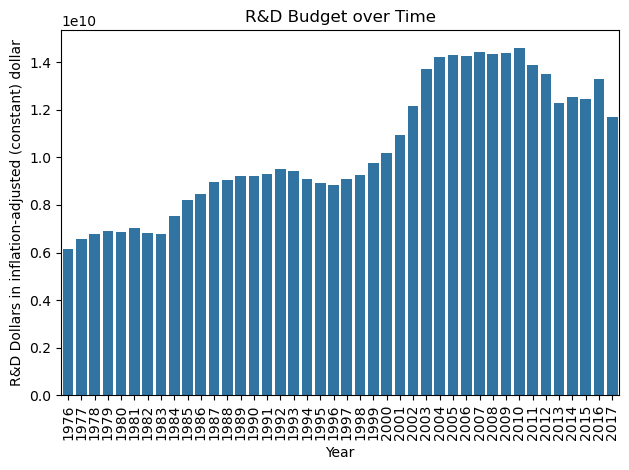

In [164]:
# Visualizating R&D Budgets over time
sns.barplot(data = df, x = "year", y = "rd_budget", errorbar = None)
plt.title("R&D Budget over Time")
plt.xlabel("Year")
plt.ylabel("R&D Dollars in inflation-adjusted (constant) dollar")
plt.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

## Step 8: GDP Over Time

A bar chart showing U.S. GDP from 1976 to 2017, revealing consistent economic growth 
over the period with a notable dip around 2009 corresponding to the 2008 financial crisis.


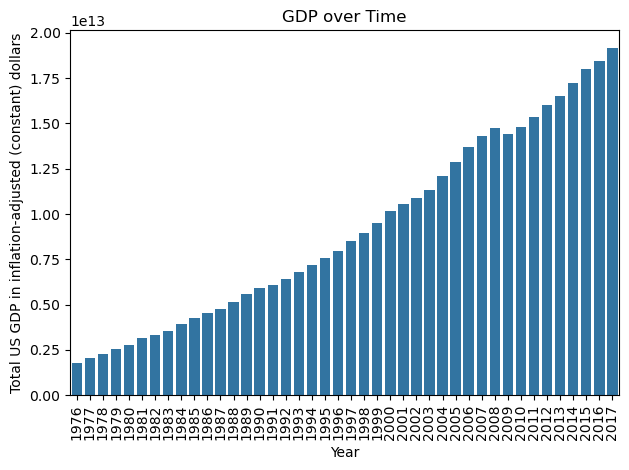

In [165]:
# Visualizing GDP over time
sns.barplot(data = df, x = "year", y = "gdp", errorbar = None)
plt.title("GDP over Time")
plt.xlabel("Year")
plt.ylabel("Total US GDP in inflation-adjusted (constant) dollars")
plt.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

## Step 9: R&D Budget by Department Over Time

A line chart breaking down R&D spending by department from 1976 to 2017.
DOD consistently leads in total spending, while HHS and NIH show the largest growth over the period.


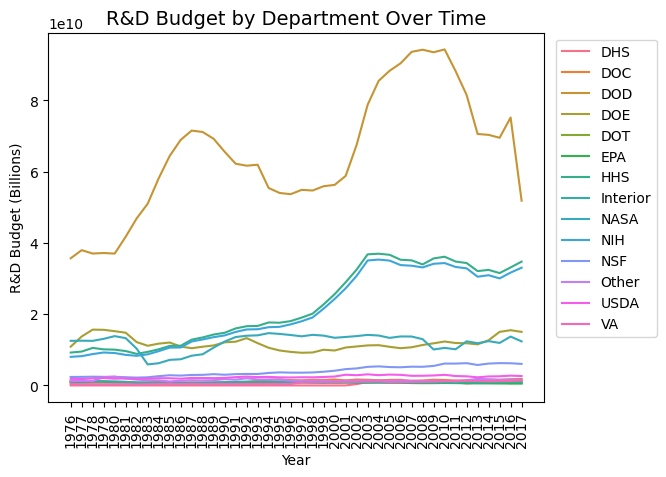

In [166]:
# Visualizing RD budget by department
sns.lineplot(data = df, x = "year", y = "rd_budget", hue = "department")
plt.title("R&D Budget by Department Over Time", fontsize = 14)
plt.xlabel("Year")
plt.ylabel("R&D Budget (Billions)")
plt.tick_params(axis = "x", rotation = 90)
plt.legend(bbox_to_anchor= (1.01, 1), loc = "upper left")
plt.show()

In [167]:
# Calculating growth rates
growth = df.groupby("department")["rd_budget"].agg(["first", "last"])
growth["growth"] = growth["last"] - growth["first"]
growth.sort_values("growth", ascending=False)

,first,last,growth
department,,,
HHS,9.226000e+09,3.475800e+10,2.553200e+10
NIH,8.025000e+09,3.305200e+10,2.502700e+10
DOD,3.569600e+10,5.186200e+10,1.616600e+10
DOE,1.088200e+10,1.503200e+10,4.150000e+09
NSF,2.372000e+09,6.040000e+09,3.668000e+09
DOC,8.190000e+08,1.824000e+09,1.005000e+09
VA,4.040000e+08,1.367000e+09,9.630000e+08
USDA,1.837000e+09,2.625000e+09,7.880000e+08
DHS,0.000000e+00,7.350000e+08,7.350000e+08


## Step 10: Mean R&D Budget by Department

A bar chart showing the average annual R&D budget per department across all years (1976–2017).
DOD has the highest mean by far, followed by HHS and NIH. 


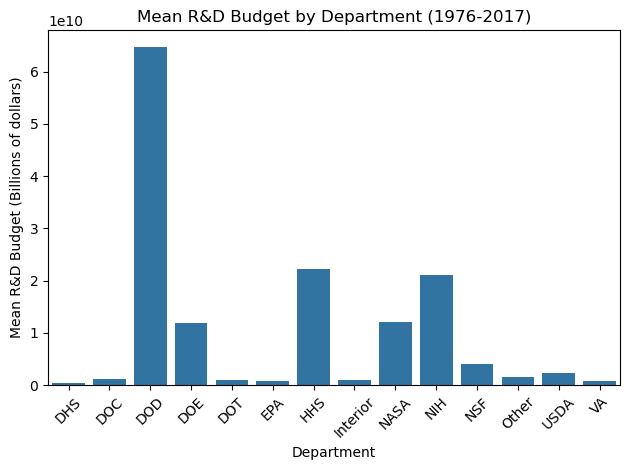

In [168]:
# Visualizing the mean R&D budget by department across all years
sns.barplot(data = df, x = "department", y = "rd_budget", estimator = "mean", errorbar = None)

plt.title("Mean R&D Budget by Department (1976-2017)")
plt.xlabel("Department")
plt.ylabel("Mean R&D Budget (Billions of dollars)")
plt.tick_params(axis = "x", rotation = 45)

plt.tight_layout()
plt.show()


## Conclusion

This project successfully transformed a wide, messy dataset into a tidy, analysis-ready format. 
By melting year columns, splitting combined fields, fixing data types, and handling missing values, 
the data became structured enough to reveal meaningful insights.

Key takeaways:
- **DOD** has consistently received the largest share of federal R&D funding
- **HHS and NIH** showed the greatest growth over the 40-year period
- **NASA, DOT, EPA, and Interior** saw budget declines by 2017
- Overall federal R&D spending and U.S. GDP both trended upward from 1976 to 2017
